In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
try:
    import catboost as cb
except:
    ! pip install catboost
    import catboost as cb

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.0' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_dirname_output = './output'
flt_threshold = 0.80
int_n_rounds = 100
str_eval_metric = 'AUC'

str_id = 'uniqueid'
str_datecol = 'applicationdate__app'
str_target = 'target'

list_cols_id = [
    str_id,
    str_datecol,
    str_target,
]

Project: 20231010-gen-xii


### Output

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Get features missing ```>=``` threshold of proportion ```NaN```

In [4]:
# rm via prop nan threshold
list_cols_nan = []
for str_df in tqdm (['train','valid','test']):
    # import descriptives
    str_filename = f'df_descriptives_{str_df}.csv'
    str_local_path = f'../../04_eda_pt_2/output/{str_filename}'
    df = pd.read_csv(str_local_path)
    # subset
    df_tmp = df[df['propna'] >= flt_threshold].copy()
    # get features
    list_cols = list(df_tmp['feature'])
    # extend
    list_cols_nan.extend(list_cols)

# rm dups
list_cols_nan = list(dict.fromkeys(list_cols_nan))
# make sure certain features are not in the list
list_cols_ignore = [
    'inttype__app',
]
list_cols_nan = [col for col in list_cols_nan if col not in list_cols_ignore]
print(f'There are {len(list_cols_nan)} features missing in at least {flt_threshold} proportion of rows')

100%|██████████| 3/3 [00:00<00:00, 105.87it/s]

There are 620 features missing in at least 0.8 proportion of rows


### Get features with all nan, no variance, or redundancy in train, valid, or test

In [5]:
%%time

# import
str_filename = 'df_cols_drop.csv'
str_local_path = f'../01_nan_novar_redundancy/output/{str_filename}'
df = pd.read_csv(str_local_path)

# get list
list_cols_allnan_novar_red = list(df['feature'])
print(f'There were {len(list_cols_allnan_novar_red)} with all nan, no var, or redundancy in train, valid, or test')
print('')

There were 459 with all nan, no var, or redundancy in train, valid, or test

CPU times: user 1.88 ms, sys: 0 ns, total: 1.88 ms
Wall time: 1.52 ms


### Get features identified as problematic by name

In [6]:
%%time

str_filename = 'df_cols_drop.csv'
str_local_path = f'../02_name/output/{str_filename}'
df = pd.read_csv(str_local_path)

# get list
list_cols_name = list(df['feature'])
print(f'There were {len(list_cols_name)} features identified as problematic by name')
print('')

There were 335 features identified as problematic by name

CPU times: user 1.22 ms, sys: 0 ns, total: 1.22 ms
Wall time: 1.11 ms


### Combine the lists

In [7]:
%%time

list_cols_bad = list_cols_nan + list_cols_allnan_novar_red + list_cols_name
# rm dups
list_cols_bad = list(dict.fromkeys(list_cols_bad))
print(f'There are {len(list_cols_bad)} bad features')
print('')

There are 924 bad features

CPU times: user 329 µs, sys: 0 ns, total: 329 µs
Wall time: 301 µs


### Get a list of all columns and make sure ```target``` is in the list

In [8]:
%%time

# import descriptives
str_filename = f'df_descriptives_train.csv'
str_local_path = f'../../04_eda_pt_2/output/{str_filename}'
df = pd.read_csv(str_local_path)
# get features
list_cols = list(df['feature'])

# rm leaky features
list_cols = [col for col in list_cols if col not in list_cols_bad]

# append target
list_cols.append(str_target)

# rm dups
list_cols = list(dict.fromkeys(list_cols))

# message
print(f'There are {len(list_cols)-1} features that will be checked for leakiness')
print('')

There are 1561 features that will be checked for leakiness

CPU times: user 27.6 ms, sys: 3.7 ms, total: 31.3 ms
Wall time: 30.8 ms


### Import training data

In [9]:
%%time

str_filename = 'df_train_raw.gzip'
str_uri = f's3://{str_project}/01_ad/01_data_prep/03_train_valid_test_split/{str_filename}'
df_train = pd.read_parquet(str_uri, columns=list_cols)

# sample
df_train = df_train.sample(frac=0.01, random_state=42)

# replace
df_train.replace(['NaN','nan'], np.nan, inplace=True)

# get non numeric
list_cols_non_numeric = []
for col in df_train.columns:
    if df_train[col].dtype not in ['float64','int64']:
        list_cols_non_numeric.append(col)
# set as string
df_train[list_cols_non_numeric] = df_train[list_cols_non_numeric].astype(str)

# fillna
df_train.fillna(0, inplace=True)

# show
df_train

CPU times: user 57.8 s, sys: 2min 18s, total: 3min 16s
Wall time: 9.11 s


,inttype__app,linkf060__tu,linkf045__tu,linkf079__tu,linkf185__tu,linkf105__tu,linkf195__tu,linkf193__tu,linkb012__tu,linkf032__tu,...,linkf001__tu,fltallowance__app,fltinsureddisabilityamount__app,fltdowncash__app,bitdealerapplicantsamezip__app,bitdealerapplicantsamecity__app,bitdealerapplicantsamestate__app,bitdebtor__app,bitdealertrack__app,target
1565428,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0
1652931,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1
917065,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0
844885,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1
860438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1345829,0.0,0.0,0.0,0.0,0.0,124.0,124.0,124.0,0.0,N,...,HIT,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1
974025,7.0,0.0,0.0,0.0,1511.0,1511.0,1937.0,1511.0,0.0,N,...,HIT,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0
1388237,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0
1608706,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0


### Import validation data

In [10]:
%%time

str_filename = 'df_valid_raw.gzip'
str_uri = f's3://{str_project}/01_ad/01_data_prep/03_train_valid_test_split/{str_filename}'
df_valid = pd.read_parquet(str_uri, columns=list_cols)

# sample
df_valid = df_valid.sample(frac=0.01, random_state=42)

# replace
df_valid.replace(['NaN','nan'], np.nan, inplace=True)

# set as string
df_valid[list_cols_non_numeric] = df_valid[list_cols_non_numeric].astype(str)

# fillna
df_valid.fillna(0, inplace=True)

# show
df_valid

CPU times: user 19.4 s, sys: 44 s, total: 1min 3s
Wall time: 4.12 s


,inttype__app,linkf060__tu,linkf045__tu,linkf079__tu,linkf185__tu,linkf105__tu,linkf195__tu,linkf193__tu,linkb012__tu,linkf032__tu,...,linkf001__tu,fltallowance__app,fltinsureddisabilityamount__app,fltdowncash__app,bitdealerapplicantsamezip__app,bitdealerapplicantsamecity__app,bitdealerapplicantsamestate__app,bitdebtor__app,bitdealertrack__app,target
1907412,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1855701,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0
225986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,3000.0,0.0,0.0,0.0,1.0,1.0,0
2032542,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0
1862702,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2051837,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1
1942956,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1
1846269,13.0,0.0,0.0,216.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0
167760,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,...,CLEAR,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0


### List of columns to check for leakiness

In [11]:
%%time

# columns to check for drift
list_cols_model = [col for col in list_cols if col not in list_cols_id]
print(f'After ensuring no ID columns nor the target are in the model, there are {len(list_cols_model)} columns to check for leakiness')
print('')

After ensuring no ID columns nor the target are in the model, there are 1561 columns to check for leakiness

CPU times: user 129 µs, sys: 293 µs, total: 422 µs
Wall time: 381 µs


### Iterate, build models, and remove the top feature

In [12]:
%%time

# build models and remove the top feature
list_feats_checked = []
list_dict_row = []
for a in tqdm(range(int_n_rounds), total=int_n_rounds, desc='Building Models'):
    # new list
    list_cols_tmp = [col for col in list_cols_model if col not in list_feats_checked]
    
    # get non numeric
    list_cols_non_numeric = []
    for col in list_cols_tmp:
        if df_train[col].dtype not in ['float64','int64']:
            list_cols_non_numeric.append(col)
    
    # train
    pool_train = cb.Pool(
        df_train[list_cols_tmp], 
        df_train[str_target], 
        cat_features=list_cols_non_numeric,
    )
    # valid
    pool_valid = cb.Pool(
        df_valid[list_cols_tmp], 
        df_valid[str_target], 
        cat_features=list_cols_non_numeric,
    )
    
    # init class
    cls_model_inference = cb.CatBoostClassifier(
        task_type='CPU',
        nan_mode='Min',
        random_state=42,
        eval_metric=str_eval_metric,
        iterations=100,
        monotone_constraints=None,
        class_weights=None,
    )
    
    # fit
    cls_model_inference.fit(
        pool_train,
        eval_set=[pool_valid],
        verbose=False,
        use_best_model=True,
        early_stopping_rounds=10, 
    )
    
    # get most important feature
    df_imp = pd.DataFrame({
        'feature': list(cls_model_inference.feature_names_),
        'importance': list(cls_model_inference.get_feature_importance()),
    })
    df_imp.sort_values(by='importance', ascending=False, inplace=True)
    
    # make dict
    dict_row = {
        'iteration': a+1,
        'feature': df_imp['feature'].iloc[0],
        'importance': df_imp['importance'].iloc[0],
        'train_score': cls_model_inference.get_best_score()['learn']['Logloss'],
        'valid_score': cls_model_inference.get_best_score()['validation']['Logloss'],
        'best_iteration': cls_model_inference.get_best_iteration(),
    }
    list_dict_row.append(dict_row)
    
    # make df
    df_dict_row = pd.DataFrame(list_dict_row)
    list_feats_checked = list(df_dict_row['feature'])

Building Models: 100%|██████████| 100/100 [05:14<00:00,  3.14s/it]

CPU times: user 4h 29min 22s, sys: 13min 43s, total: 4h 43min 6s
Wall time: 5min 14s


### View df

In [13]:
# show
df_dict_row

,iteration,feature,importance,train_score,valid_score,best_iteration
0,1,inttype__app,6.135236,0.543935,0.594022,23
1,2,fltapprovedpayment__app,13.056394,0.567199,0.606782,6
2,3,intterm__app,3.525808,0.537913,0.603344,34
3,4,linka013__tu,8.053625,0.564617,0.607250,7
4,5,linka017__tu,8.597219,0.567033,0.609103,6
...,...,...,...,...,...,...
95,96,g307s__tu,1.503061,0.518542,0.603069,66
96,97,bc20s__tu,2.208353,0.531736,0.599428,51
97,98,at104s__tu,2.638966,0.555299,0.604359,24
98,99,g003s__tu,2.304748,0.545733,0.601005,39


### Plot scores by iteration

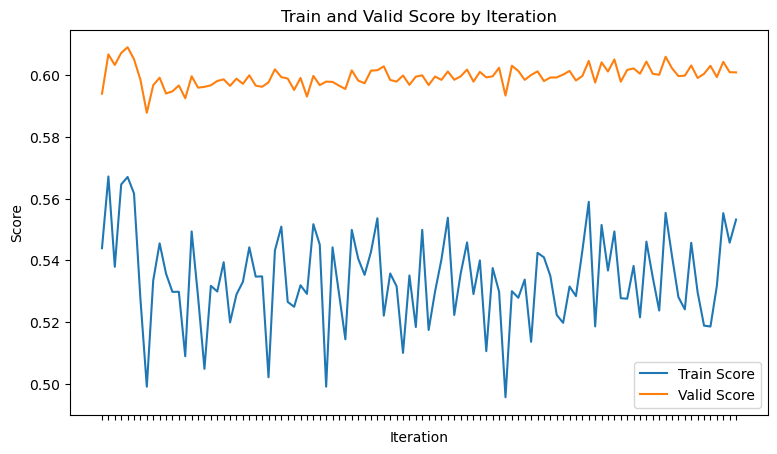

In [14]:
# plot
#int_n_features = 15
#int_n_features_drop = 46
fig, ax = plt.subplots(figsize=(9,5))
str_title = 'Train and Valid Score by Iteration'
ax.set_title(str_title)
ax.set_xlabel('Iteration')
ax.set_xticklabels([])
ax.set_ylabel('Score')
ax.plot(df_dict_row['iteration'].astype(str), df_dict_row['train_score'], label='Train Score')
ax.plot(df_dict_row['iteration'].astype(str), df_dict_row['valid_score'], label='Valid Score')
#ax.axvline(x=int_n_features, color='red', linestyle='--', label=f'{int_n_features} Features')
#ax.axvline(x=int_n_features_drop, color='black', linestyle='--', label=f'{int_n_features_drop} Features')
# legend
plt.legend()

# save
str_filename = 'plt_score_by_iteration.png'
str_local_path = f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

### Tag as leaky or not

In [15]:
# %%time

# # tag as leaky
# df_dict_row['leaky'] = df_dict_row['iteration'].apply(
#     lambda x: 1 if x <= int_n_features else 0,
# )

# # show
# df_dict_row.head(int_n_features+5)

### Save df

In [16]:
%%time

str_filename = 'df_leaky_models.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_dict_row.to_csv(str_local_path, index=False)

CPU times: user 1.91 ms, sys: 118 µs, total: 2.02 ms
Wall time: 1.9 ms


### Tag and save df

In [17]:
%%time

# make list
#list_cols_leaky = list(df_dict_row['feature'])[:int_n_features]

# combine lists
#list_cols_bad = list_cols_bad + list_cols_leaky
# rm dups
list_cols_bad = list(dict.fromkeys(list_cols_bad))

# make df
df = pd.DataFrame({'feature': list_cols_bad})

# tag
df['from_nan'] = df['feature'].apply(
    lambda x: 1 if x in list_cols_nan else 0,
)

# tag
df['from_df'] = df['feature'].apply(
    lambda x: 1 if x in list_cols_allnan_novar_red else 0,
)

# tag
df['from_name'] = df['feature'].apply(
    lambda x: 1 if x in list_cols_name else 0,
)

# # tag
# df['from_models'] = df['feature'].apply(
#     lambda x: 1 if x in list_cols_leaky else 0,
# )

# sum
list_cols = [
    'from_nan',
    'from_df',
    'from_name',
    #'from_models'
]
df['sum'] = df[list_cols].sum(axis=1)

# sort
df.sort_values(by='sum', ascending=False, inplace=True)

# save
str_filename = 'df_cols_bad.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df.to_csv(str_local_path, index=False)

# show
df

CPU times: user 19.5 ms, sys: 0 ns, total: 19.5 ms
Wall time: 18.8 ms


,feature,from_nan,from_df,from_name,sum
73,dtmfunded__base,1,1,1,3
74,observationdate__base,1,1,1,3
177,score_bankcard__tu,1,1,1,3
72,dtmdeclined__base,1,1,1,3
71,dtmapproved__base,1,1,1,3
...,...,...,...,...,...
310,ad14g__tu,1,0,0,1
311,ad14f__tu,1,0,0,1
312,ad14e__tu,1,0,0,1
313,ad14d__tu,1,0,0,1
